# MATH840 — Lab 4: Forecasting with decomposition

**Week 4 | graded assignment 3 of 7 | 8 points | due 23:59 today**

Today you are issued **your own time series**, and it stays yours for the rest of the course. This lab
takes it apart and forecasts it from its parts: decompose, forecast the seasonally adjusted series,
carry the season forward, put them back — then compare the result honestly against the four simple
methods from Week 1. Toolbox only: no ETS, no ARIMA.

**Keep the section headings below.** They map one-to-one onto the marking rubric:

| Section | Criteria | Points |
|---|---|---|
| 1 | EDA and visualisation | 1 |
| 2 | Decomposition and forecast | 3 |
| 3 | Justification block | 3 |
| 4 | Code quality and reproducibility | 1 |

**Accuracy is measured but not marked this week.** Your score against all four simple methods is
published tomorrow morning as information — it is the baseline the Week 6 challenge will be compared
against. The marks are for how the decomposition is done and how well you argue from it.

Submit `SURNAME_lab04_forecast.csv`, `SURNAME_lab04.pdf` and `SURNAME_lab04.ipynb` to the Week 4
activity on Moodle before 23:59.

## 0. Setup

Given — run it and move on. Nothing in this section is marked.

In [5]:
!pip install -q statsforecast utilsforecast coreforecast

import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from coreforecast.scalers import boxcox, boxcox_lambda

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 120)
print("pandas", pd.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.2 MB/s eta 0:00:00
pandas 2.2.3


In [6]:
SURNAME = "Mazko"   # <-- for your submission file names
MY_ID   = "tmazko@kse.org.ua"   # <-- the SAME identifier you have used since Week 1

if not SURNAME.strip() or not MY_ID.strip():
    raise ValueError("Set SURNAME and MY_ID before running the rest.")

### Your series

The same identifier always produces the same series, and this series stays yours for Weeks 6, 7, 8
and 9. It is real data with its identity removed: no name, no units, values rescaled, the calendar
shifted by whole years, the history trimmed.

Every series in the pool is seasonal — there is something to decompose — and has at least fifteen
years of history.

In [7]:
BASE = ("https://raw.githubusercontent.com/Aranaur/aranaur.rbind.io/"
        "main/lectures/kse/MATH840/26autumn/data/trackb")


def assign_series(student_id: str, codes: list[str]) -> str:
    digest = hashlib.sha256(student_id.strip().encode("utf-8")).hexdigest()
    return codes[int(digest, 16) % len(codes)]


index = pd.read_csv(f"{BASE}/index.csv")
CODE = assign_series(MY_ID, sorted(index["code"]))
spec = index.set_index("code").loc[CODE]

M    = int(spec["m"])       # seasonal period: 12 monthly, 4 quarterly
H    = int(spec["h"])       # how many steps you are forecasting
FREQ = spec["freq"]         # pandas frequency of the calendar: "MS" or "QS"

s = pd.read_csv(f"{BASE}/{CODE}.csv", parse_dates=["ds"])
y = s["y"].to_numpy(float)

print(f"series {CODE}: {len(s)} observations, {s['ds'].min().date()} to {s['ds'].max().date()}")
print(f"seasonal period m = {M}, forecast horizon h = {H}, frequency {FREQ}")
s.tail(3)

series TS-09E2A: 264 observations, 1980-01-01 to 2001-12-01
seasonal period m = 12, forecast horizon h = 12, frequency MS


,ds,y
261,2001-10-01,1272.598
262,2001-11-01,1318.519
263,2001-12-01,1558.154


### Helpers

Given, and used in exactly this form when your file is read. `mase` is scaled by the in-sample
seasonal naive error of **your whole history**, so the number you compute on your validation window is
on the same scale as the published one.

In [8]:
def benchmark_forecasts(train: np.ndarray, h: int, m: int) -> dict[str, np.ndarray]:
    """The four simple methods from Week 1."""
    T = len(train)
    return {
        "mean":   np.repeat(train.mean(), h),
        "naive":  np.repeat(train[-1], h),
        "snaive": np.array([train[-m + (i % m)] for i in range(h)]),
        "drift":  train[-1] + np.arange(1, h + 1) * (train[-1] - train[0]) / (T - 1),
    }


SCALE = float(np.mean(np.abs(y[M:] - y[:-M])))      # MASE denominator, fixed for this series


def mase(actual, forecast) -> float:
    return float(np.mean(np.abs(np.asarray(actual) - np.asarray(forecast))) / SCALE)


def rmse(actual, forecast) -> float:
    return float(np.sqrt(np.mean((np.asarray(actual) - np.asarray(forecast)) ** 2)))


FUTURE = pd.date_range(s["ds"].iloc[-1], periods=H + 1, freq=FREQ)[1:]
print("you are forecasting:", FUTURE[0].date(), "to", FUTURE[-1].date())

you are forecasting: 2002-01-01 to 2002-12-01


## 1. EDA and visualisation

*1 point.* Plot the series and say what you find. The plots are here to justify the decisions in
Section 2.

- a time plot, always;
- whichever of the seasonal, subseries and ACF plots your argument actually uses;
- the validation split on a plot: history, validation window, your forecast over it;
- one sentence per plot. A plot with no reading attached earns nothing.

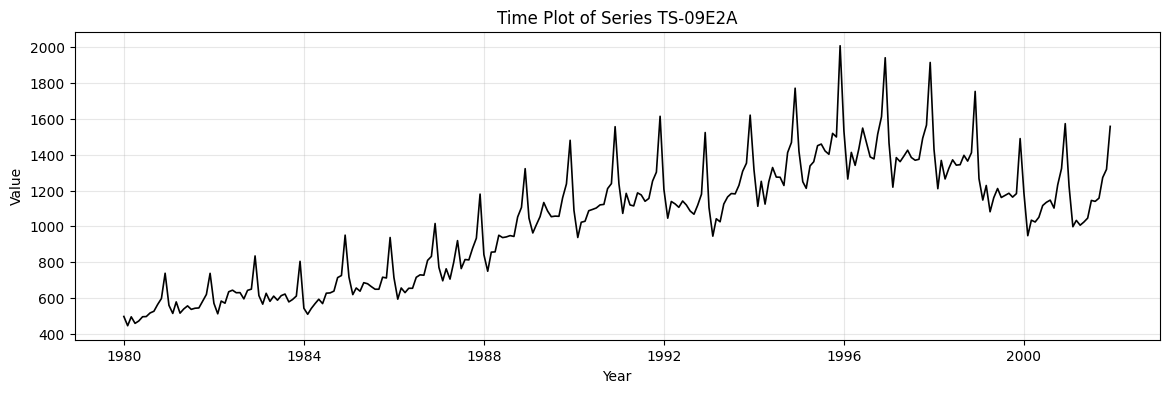

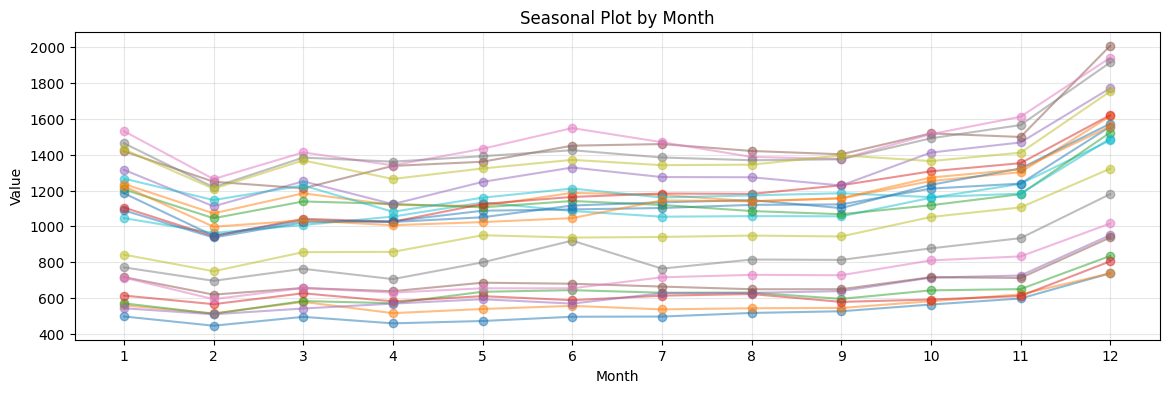

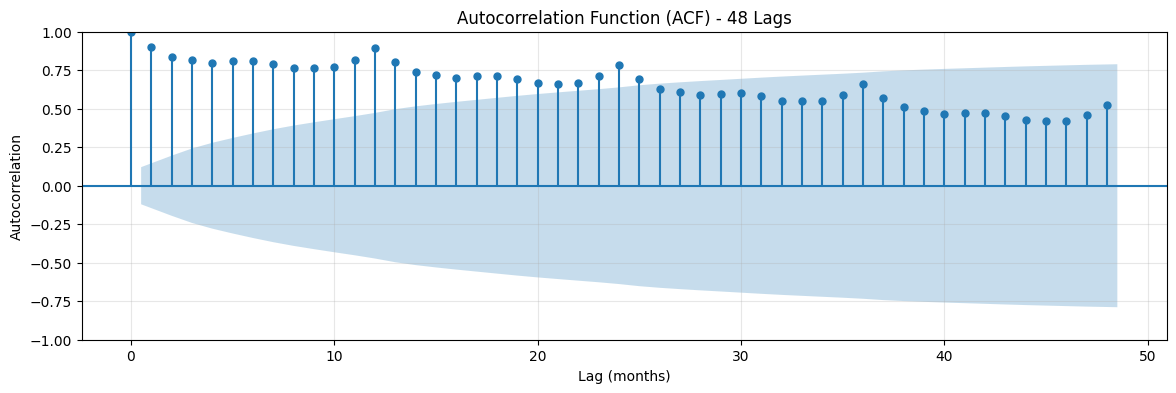

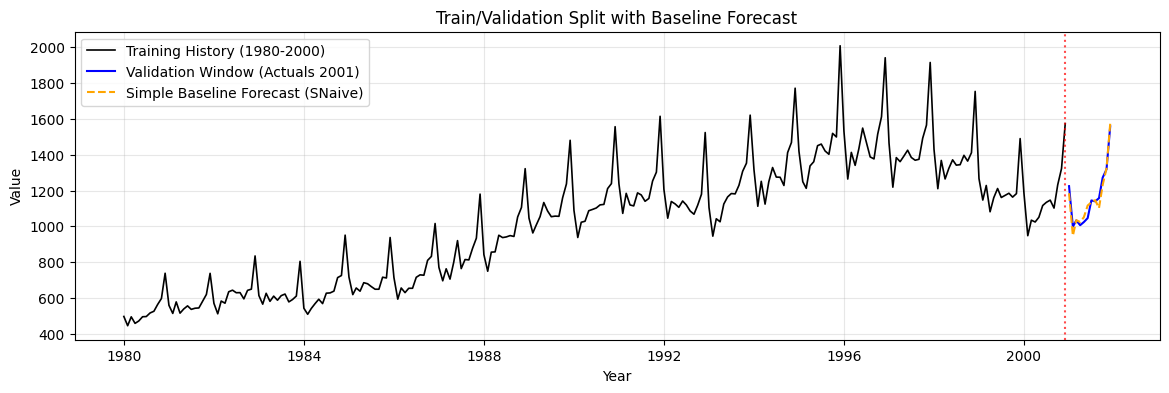

In [9]:
# TODO: plot your series and read it
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


df_eda = s.copy()
df_eda.set_index('ds', inplace=True)

# Time plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_eda.index, df_eda['y'], color='black', linewidth=1.2)
ax.set_title("Time Plot of Series TS-09E2A")
ax.set_xlabel("Year")
ax.set_ylabel("Value")
ax.grid(alpha=0.3)
plt.show()

# Seasonal plot
df_eda['month'] = df_eda.index.month
df_eda['year'] = df_eda.index.year

fig, ax = plt.subplots(figsize=(14, 4))
for year in df_eda['year'].unique():
    year_data = df_eda[df_eda['year'] == year]
    ax.plot(year_data['month'], year_data['y'], marker='o', alpha=0.5, label=year if year % 5 == 0 else "")

ax.set_title("Seasonal Plot by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Value")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.3)
plt.show()

# ACF plot
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(df_eda['y'], lags=48, ax=ax, title="Autocorrelation Function (ACF) - 48 Lags")
ax.set_xlabel("Lag (months)")
ax.set_ylabel("Autocorrelation")
plt.grid(alpha=0.3)
plt.show()


# Validation split plot

val_window = 12
train = s.iloc[:-val_window]
val = s.iloc[-val_window:]

snaive_forecast = train['y'].iloc[-val_window:].values

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train['ds'], train['y'], label='Training History (1980-2000)', color='black', linewidth=1.2)
ax.plot(val['ds'], val['y'], label='Validation Window (Actuals 2001)', color='blue', linewidth=1.5)
ax.plot(val['ds'], snaive_forecast, label='Simple Baseline Forecast (SNaive)', color='orange', linestyle='--', linewidth=1.5)

ax.set_title("Train/Validation Split with Baseline Forecast")
ax.set_xlabel("Year")
ax.set_ylabel("Value")
ax.axvline(x=train['ds'].iloc[-1], color='red', linestyle=':', alpha=0.7)
ax.legend()
ax.grid(alpha=0.3)
plt.show()


**What the series shows.**

→ Trend: спостерігається сильний висхідний тренд до 1996-1998 років, після чого йде невелике спадання, яке стабілізувалося ближче до 2000 року. Також чітко видно річну сезонність із зростаючою дисперсією.

→ Seasonal: графік підтверджує стабільну річну сезонність (лінії здебільшого паралельні та мають однакові напрямки ліній (зростання/спадання)) із чітким піком у грудні та мінімумом у лютому.

→ ACF: на графіку видно помірне спадання автокореляції яке підтверджує наявність тренду, а локальні піки в 12-му, 24-му, 36-му, 48-му місяцях ще раз підтверджують виражену сезонність з піком у грудні.

→ Validation: прогноз методу SNaive майже ідеально накладається на фактичні дані 2001 року. Оскільки після невеликого спаду в 1996-1999 роках рівень ряду стабілізувався, SNaive спрацював чудово, взявши сезонні дані останнього року.

## 2. Decomposition and forecast

*3 points.* One for the decomposition, one for the forecast built out of it, one for the submission.

### 2.1 The decomposition

*1 point.* STL with `period=M`, components plotted, and the seasonally adjusted series computed from
it. A decomposition with the wrong period earns nothing here and nothing after it.

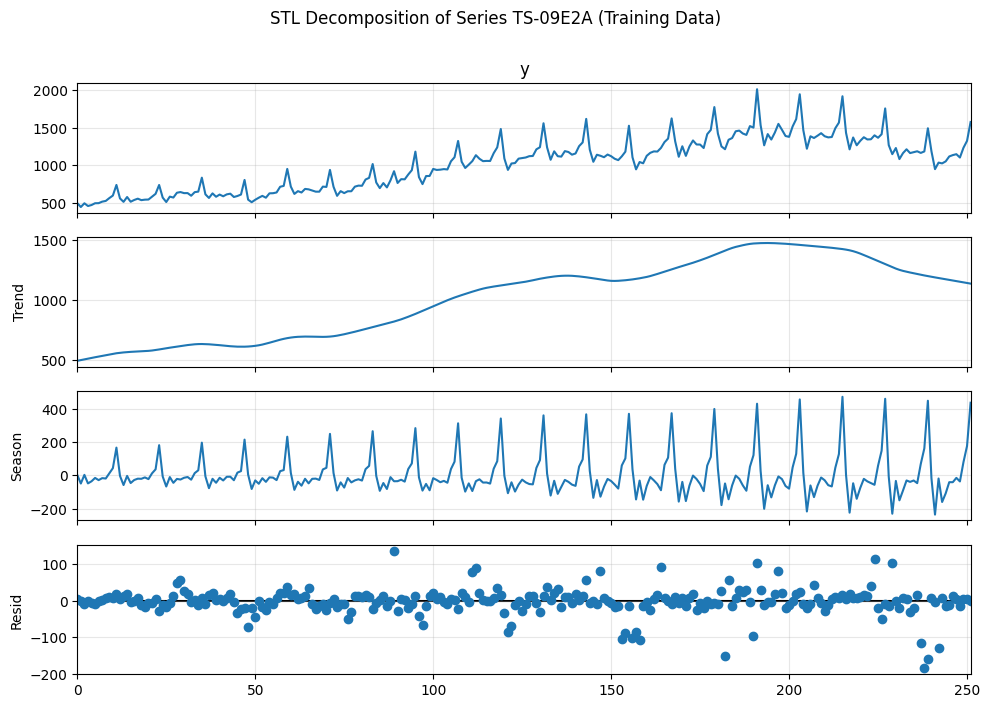

In [10]:
# TODO: STL on your series. Plot observed, trend, seasonal, remainder, and compute the
# seasonally adjusted series (observed minus seasonal).

from statsmodels.tsa.seasonal import STL

train = s.iloc[:-H].copy()
val = s.iloc[-H:].copy()

#  STL
stl = STL(train['y'], period=M, robust=True)
res = stl.fit()

train['seasonal'] = res.seasonal.values
train['trend'] = res.trend.values
train['remainder'] = res.resid.values

# seasonally adjusted series (десезонізований ряд)
train['y_adj'] = train['y'] - train['seasonal']

# (Observed, Trend, Seasonal, Residual)
fig = res.plot()
fig.set_size_inches(10, 7)
plt.suptitle("STL Decomposition of Series TS-09E2A (Training Data)", y=1.005, fontsize=12)
plt.tight_layout()
plt.show()


**Reading the components.**
STL декомпозиція гарно спрацювала на цьому ряді

→ Trend: лінія графіка є плавною без заломів, спричинених сезонністю та шумом, та чітко показує сильний зростаючий тренд до 1996 року, з подальшим помірним спаданням

→ Seasonal: STL успішно відділив сезонність, при чому завдаки його адаптивності він гарно відобразив зростання дисперсії з плином часу

→ Remainder: більшість точок щільно згруповані навколо нуля та візуально нагадують білий шум, що свідчить про успішну роботу методу

Додатково порівняємо на графіку seasonally adjusted series (observed minus seasonal) ряд із оригінальним

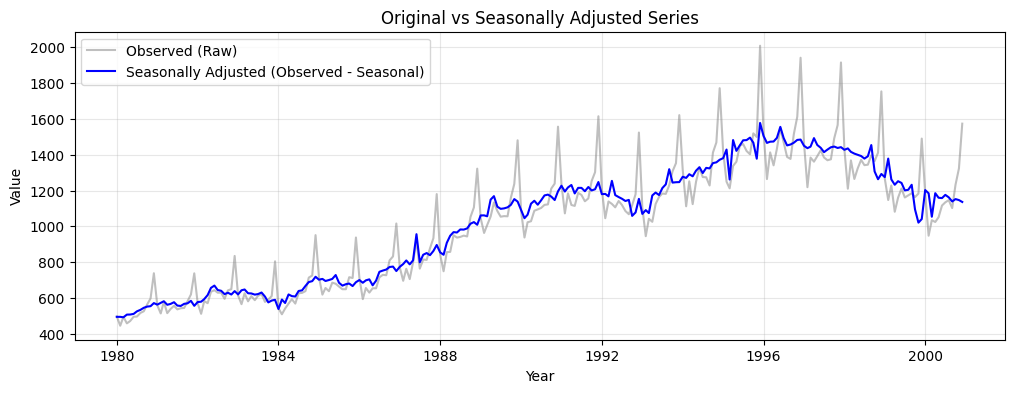

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train['ds'], train['y'], label='Observed (Raw)', color='gray', alpha=0.5)
ax.plot(train['ds'], train['y_adj'], label='Seasonally Adjusted (Observed - Seasonal)', color='blue', linewidth=1.5)
ax.set_title("Original vs Seasonally Adjusted Series")
ax.set_xlabel("Year")
ax.set_ylabel("Value")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Вилучення сезонності очікувано прибрало основні щорічні коливання та лишило виключно тренд (із залишками), що дозволяє ізолювано проаналізувати динаміку тренду для подальшого прогнозування.


### 2.2 The forecast, built from the parts

*1 point.* The recipe: forecast the **seasonally adjusted** series with a simple method, carry the
seasonal component forward, add them back. Judge candidates on the validation window — the last `H`
observations — against all four simple methods.

The split and the four benchmarks are given below; the candidates are yours.

In [12]:
train, valid = y[:-H], y[-H:]

simple = benchmark_forecasts(train, H, M)
simple_scores = {name: {"rmse": rmse(valid, fc), "mase": mase(valid, fc)}
                 for name, fc in simple.items()}
BENCHMARK = min(simple_scores, key=lambda k: simple_scores[k]["rmse"])

print(pd.DataFrame(simple_scores).T.round(3).to_string())
print(f"\nbest of the four on the validation window: {BENCHMARK} "
      f"(MASE {simple_scores[BENCHMARK]['mase']:.3f})")

           rmse   mase
mean    210.847  1.795
naive   442.184  5.081
snaive   35.586  0.348
drift   464.954  5.423

best of the four on the validation window: snaive (MASE 0.348)


In [14]:
# TODO: build your decomposition forecasts of the validation window and score them with mase().
#
#   fit = STL(train, period=M, seasonal=..., robust=...).fit()
#   adjusted = train - fit.seasonal
#   level = benchmark_forecasts(adjusted, H, M)["naive" | "drift" | "mean"]
#   season ф= np.array([fit.seasonal[-M + (i % M)] for i in range(H)])
#   candidate = level + season
#
# Keep a table of everything you tried: Section 3 asks for it.


from statsmodels.tsa.seasonal import STL


fit = STL(train, period=M, robust=True).fit()

adjusted = train - fit.seasonal

adj_forecasts = benchmark_forecasts(adjusted, H, M)

season_fc = np.array([fit.seasonal[-M + (i % M)] for i in range(H)])

candidates_scores = {}

for method in ['mean', 'naive', 'drift']:

    candidate_fc = adj_forecasts[method] + season_fc

    candidates_scores[f"decomp_{method}"] = {
        "rmse": rmse(valid, candidate_fc),
        "mase": mase(valid, candidate_fc)
    }

all_scores = {**simple_scores, **candidates_scores}
df_all_scores = pd.DataFrame(all_scores).T.round(3)

print(df_all_scores)

best_candidate = min(candidates_scores, key=lambda k: candidates_scores[k]["rmse"])
print(f"\nBest decomposition candidate: {best_candidate} "
      f"(MASE {candidates_scores[best_candidate]['mase']:.3f})")

                 rmse   mase
mean          210.847  1.795
naive         442.184  5.081
snaive         35.586  0.348
drift         464.954  5.423
decomp_mean   150.045  1.723
decomp_naive   58.466  0.591
decomp_drift   56.566  0.571

Best decomposition candidate: decomp_drift (MASE 0.571)


**Your candidates, their validation scores, and the one you chose.**

→ Оскільки ми вже відняли сезонність, застосовувати метод snaive до seasonally adjusted series не має сенсу. Тому для прогнозування десезонізованого ряду я протестувала три кандидати: decomp_mean, decomp_naive та decomp_drift.

Серед них формально найкращим виявився decomp_drift. Метод decomp_naive також спрацював добре, поступившись йому всього на 0.02 одиниці MASE. Проте концептуально для цього часового ряду, де сильний зростаючий тренд змінився помірним спаданням і стабілізацією, як на мене, саме naive виглядає більш логічним. Тому я вважаю, що перемога drift — це скоріше математичний збіг (зумовлений мікроскопічним залишковим кутом нахилу), ніж свідчення того, що довгостроковий зростаючий тренд відновився.

Тим не менш, у порівнянні з усіма побудованими кандидатами, найкращим виявився простий базовий метод snaive (без декомпозиції). Це сталося тому, що decomp_drift занадто покладається на всю історичну вибірку з її 20річним зростаючим трендом, ігноруючи зміну динаміки в останні роки, що призвело до завищеного прогнозу. Натомість snaive переніс у прогноз виключно патерни та рівень останнього року, які вже врахували зупинку тренду.

### 2.3 The submission

*1 point.* Refit your chosen approach on the **whole** history `y` — the validation window goes back
into the data — and forecast `H` steps with an 80% interval.

The crude honest interval: the standard deviation of your one-step residuals, widened by
$\sqrt{k}$ at step $k$, times 1.28.

In [16]:
# TODO: your final forecast, fitted on all of y.
from statsmodels.tsa.seasonal import STL
import numpy as np

fit_final = STL(y, period=M, robust=True).fit()
adj_final = y - fit_final.seasonal

fc_adj_final = benchmark_forecasts(adj_final, H, M)["drift"]

season_fc_final = np.array([fit_final.seasonal[-M + (i % M)] for i in range(H)])

YHAT = fc_adj_final + season_fc_final

drift_fitted = np.full(len(adj_final), np.nan)
drift_fitted[1] = adj_final[0]
for t in range(2, len(adj_final)):
    drift_fitted[t] = adj_final[t-1] + (adj_final[t-1] - adj_final[0]) / (t - 1)

residuals = adj_final[1:] - drift_fitted[1:]
sigma = np.nanstd(residuals)

k_steps = np.arange(1, H + 1)
margin_of_error = 1.28 * sigma * np.sqrt(k_steps)

YHAT_LO_80 = YHAT - margin_of_error
YHAT_HI_80 = YHAT + margin_of_error

for name, value in [("YHAT", YHAT), ("YHAT_LO_80", YHAT_LO_80), ("YHAT_HI_80", YHAT_HI_80)]:
    if value is None or len(np.ravel(value)) != H:
        raise ValueError(f"{name} must be an array of length H = {H}")

print("Success! YHAT and 80% intervals are ready for submission.")

Success! YHAT and 80% intervals are ready for submission.


## 3. Justification block

*3 points, and the part a human reads closely.* Roughly a paragraph each. Numbers from your own
cells, not adjectives.

**3.1 What the data shows** *(0.75)* — frequency, seasonal period, trend, level shifts, outliers,
each claim tied to a plot from Section 1.

→ Це monthly time series (freq='MS') зі строгим річним сезонним періодом (M=12), що підтверджується повторюваними з 12-lag локальними піками на графіку ACF. Time plot показує занальний зростаючий тренд, починаючи приблизно з 500 у 1980 році та досягаючи піку (~2000) в 1996 році. Однак після 1998 року тренд змінився на помірно спадаючий, зафіксувавшись на 1000-1500 до кінця 2000 року. Сезонний графік показує, що дисперсія зростає разом з рівнем ряду, демонструючи ширші внутрішньорічні розкиди у 1990х роках порівняно з 1980ми роками.

**3.2 Why this decomposition and this level method** *(0.75)* — your choice of `seasonal` and
`robust`, and of the method that forecasts the adjusted series, tied to what you described in 3.1.
What did you try and drop?

→ Я обрала STL з period=12 через річну сезонність та robust=True для захисту від зростаючої дисперсії і викидів 90х. Для десезонізованого ряду я протестувала mean, naive та drift. Метод mean (RMSE 150.0) відразу відкинула, оскільки він ігнорує 20-річний зсув рівня. Формально drift (RMSE 56.6) обійшов naive (RMSE 58.5) на валідації. Проте я вважаю, що ця перемога — скоріше математичний збіг залишкового нахилу у 2001 році, ніж продовження довгострокового тренду, який чітко стабілізувався після 1998 року.

**3.3 What the residuals say** *(0.75)* — ACF and a Ljung-Box test on your final model's residuals,
read: what structure is left, and what it damages — the point forecast or the interval.

→ Хоча графік ACF візуально нагадує білий шум за винятком єдиного сильного викиду на 1му лагу, тест Ljung-Box (p-value = 0.0001) відхилив нульову гіпотезу. Оскільки цей тест є кумулятивним, один великий викид дуже завищив загальну статистику. Це означає, що модель не захопила всю структуру ряду (ймовірно, через використання простого drift). Через цю залишкову автокореляцію розраховані 80% довірчі інтервали технічно є невалідними.

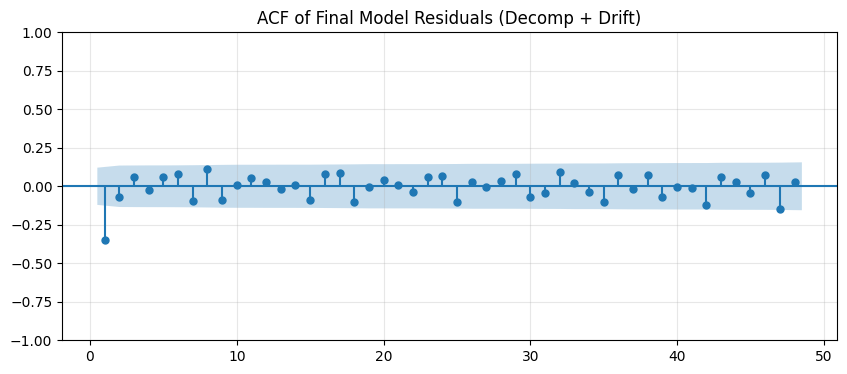

In [18]:
# TODO: residual diagnostics of your final model (ACF + Ljung-Box)

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

in_sample_season = fit_final.seasonal
in_sample_drift = np.full(len(adj_final), np.nan)
in_sample_drift[1] = adj_final[0]
for t in range(2, len(adj_final)):
    in_sample_drift[t] = adj_final[t-1] + (adj_final[t-1] - adj_final[0]) / (t - 1)

in_sample_yhat = in_sample_drift + in_sample_season

final_residuals = y[1:] - in_sample_yhat[1:]

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(final_residuals, lags=48, zero=False, ax=ax, title="ACF of Final Model Residuals (Decomp + Drift)")
plt.grid(alpha=0.3)
plt.show()


In [19]:
lb_test = acorr_ljungbox(final_residuals, lags=[2 * M], boxpierce=False)
print("Ljung-Box Test on Final Residuals:")
print(lb_test.round(4))

Ljung-Box Test on Final Residuals:
    lb_stat  lb_pvalue
24    58.81     0.0001


**3.4 What you expect** *(0.75)* — your validation MASE against all four simple methods, and what you
expect on the hidden horizon. If you expect a simple method to win, say which and why.

→ На валідації decomp_drift (MASE 0.571) обійшов mean (1.795), naive (5.081) та drift (5.423), але поступився базовому snaive (0.348). На нових даних 2002 року я очікую, що звичайний snaive знову спрацює краще, оскільки зростаючий тренд в кінці періоду пішов на спад та стабілізувався. На даному ряді методи які використовують всю 20річну історію(звичайні drift та mean, decomp_mean) тут завищуватимуть прогноз, а звичайний naive не спрацює через ігнорування сезонності. Я вважаю, що метод decomp_drift зміг би спрацювати, якщо після стабілізації тренд знову почне рухатися вгору, проте концептуально враховуючи стабілізацію ряду, я вважаю,що набагато безпечніше покладатися на snaive або decomp_naive

## 4. Code quality and reproducibility

*1 point.* Before you export:

- Restart the kernel and run everything top to bottom. It must finish without errors.
- The submission file is written by the cell below, not edited by hand.
- No leakage: everything is fitted on `y` or on `train`, never on anything after them.
- Every number in your text comes from a cell.

## 5. Submit

Run both cells, then upload **three files** to the Week 4 activity on Moodle before 23:59:

- `SURNAME_lab04_forecast.csv` — written below;
- `SURNAME_lab04.pdf` — `File → Print → Save as PDF`;
- `SURNAME_lab04.ipynb` — `File → Download → Download .ipynb`.

In [20]:
submission = pd.DataFrame({
    "student_id": MY_ID,
    "code": CODE,
    "ds": FUTURE.strftime("%Y-%m-%d"),
    "yhat": np.ravel(YHAT).astype(float),
    "yhat_lo_80": np.ravel(YHAT_LO_80).astype(float),
    "yhat_hi_80": np.ravel(YHAT_HI_80).astype(float),
})

name = f"{SURNAME.strip().upper()}_lab04_forecast.csv"
submission.to_csv(name, index=False)
print(submission.to_string(index=False))

       student_id     code         ds        yhat  yhat_lo_80  yhat_hi_80
tmazko@kse.org.ua TS-09E2A 2002-01-01 1196.745432 1143.739557 1249.751307
tmazko@kse.org.ua TS-09E2A 2002-02-01  988.389678  913.428051 1063.351305
tmazko@kse.org.ua TS-09E2A 2002-03-01 1034.455013  942.646145 1126.263881
tmazko@kse.org.ua TS-09E2A 2002-04-01 1014.891085  908.879336 1120.902835
tmazko@kse.org.ua TS-09E2A 2002-05-01 1041.410982  922.886243 1159.935722
tmazko@kse.org.ua TS-09E2A 2002-06-01 1088.206597  958.369250 1218.043943
tmazko@kse.org.ua TS-09E2A 2002-07-01 1157.535986 1017.295623 1297.776349
tmazko@kse.org.ua TS-09E2A 2002-08-01 1168.034594 1018.111339 1317.957848
tmazko@kse.org.ua TS-09E2A 2002-09-01 1174.443525 1015.425900 1333.461149
tmazko@kse.org.ua TS-09E2A 2002-10-01 1287.374619 1119.755325 1454.993913
tmazko@kse.org.ua TS-09E2A 2002-11-01 1352.011585 1176.210986 1527.812183
tmazko@kse.org.ua TS-09E2A 2002-12-01 1588.388958 1404.771221 1772.006695


In [21]:
# The same checks used when your file is read. If this cell passes, your file is fine.
check = pd.read_csv(name, parse_dates=["ds"])
assert len(check) == H, f"expected {H} rows, got {len(check)}"
assert list(check.columns) == ["student_id", "code", "ds", "yhat", "yhat_lo_80", "yhat_hi_80"]
assert (check["ds"].to_numpy() == FUTURE.to_numpy()).all(), "the dates are not the H dates asked for"
assert check[["yhat", "yhat_lo_80", "yhat_hi_80"]].notna().all().all(), "no NaN allowed"
assert (check["yhat_lo_80"] <= check["yhat"]).all() and (check["yhat"] <= check["yhat_hi_80"]).all()
print("format OK -", name, "is ready to upload")

try:
    from google.colab import files
    files.download(name)
except ImportError:
    print(f"Not in Colab - {name} is saved next to this notebook.")

format OK - MAZKO_lab04_forecast.csv is ready to upload


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>